In [1]:
# Test script 1

In [1]:
# Option 1 for mortality equation (population weight the AF) TEST FOR 2000

In [1]:
import os
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import numpy as np

In [2]:
BMR_DIR = "/glade/work/awells/air_quality/BMR/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
O3_DIR = "/glade/work/awells/air_quality/O3_obs/"

In [3]:
bmr = xr.open_dataarray(f"{BMR_DIR}GBD_BMR_Country_Mask_COPD_1990-2009.nc")
pop_2000 = xr.open_dataarray(f"{POP_DIR}ssp2_total_regrid_2000.nc")
o3_2000 = xr.open_dataset(f"{O3_DIR}Delang_BME_OSDMA8_1990_2017.nc")["ozone"].sel(year=slice("1990", "2009")).mean("year")

In [4]:
pop_lat = pop_2000.lat.values
pop_lon = pop_2000.lon.values

o3_lat = o3_2000.latitude.values
o3_lon = o3_2000.longitude.values

bmr_lat = bmr.lat.values
bmr_lon = bmr.lon.values

In [5]:
o3_lat_mask = xr.ufuncs.logical_and(o3_lat <= pop_lat.max(), o3_lat >= pop_lat.min())
o3_lon_mask = xr.ufuncs.logical_and(o3_lon <= pop_lon.max(), o3_lon >= pop_lon.min())

bmr_lat_mask = xr.ufuncs.logical_and(bmr_lat <= pop_lat.max(), bmr_lat >= pop_lat.min())
bmr_lon_mask = xr.ufuncs.logical_and(bmr_lon <= pop_lon.max(), bmr_lon >= pop_lon.min())

In [6]:
new_o3 = o3_2000.sel(latitude=o3_lat_mask)
new_bmr = bmr.sel(lat=bmr_lat_mask)

In [7]:
o3_interp = new_o3.interp(latitude=pop_2000.lat, longitude=pop_2000.lon)
bmr_interp = new_bmr.interp(lat=pop_2000.lat, lon=pop_2000.lon)

In [8]:
RR_10ppb = 1.074
# RR = e^(beta*(x-TMREL))
beta = np.log(RR_10ppb)/10
TMREL = 32.4

In [9]:
O3_diff = o3_interp - TMREL
TMREL_O3 = xr.where(O3_diff > 0, O3_diff, 0)

In [10]:
RR = np.exp(beta * TMREL_O3)

In [11]:
AF = (RR - 1)/RR

In [12]:
pop_tot = pop_2000.sum()

In [13]:
PAF = AF * (pop_2000/pop_tot)

In [14]:
M = PAF * bmr_interp * pop_2000

In [15]:
# === Latitude weighting sum ===
def weighted_sum(da):
    weights = np.cos(np.deg2rad(da.lat))
    weights.name = "weights"
    new_da = da.weighted(weights).sum(("lon", "lat"))
    return new_da

In [16]:
new_M = weighted_sum(M)

In [17]:
new_M

<xarray.DataArray (quantile: 3)> Size: 24B
array([375128.23995823, 432590.14533244, 485309.90421674])
Coordinates:
  * quantile  (quantile) <U6 72B 'lower' 'median' 'upper'
    region    <U26 104B 'Western Sub-Saharan Africa'

In [18]:
levels = [0, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]

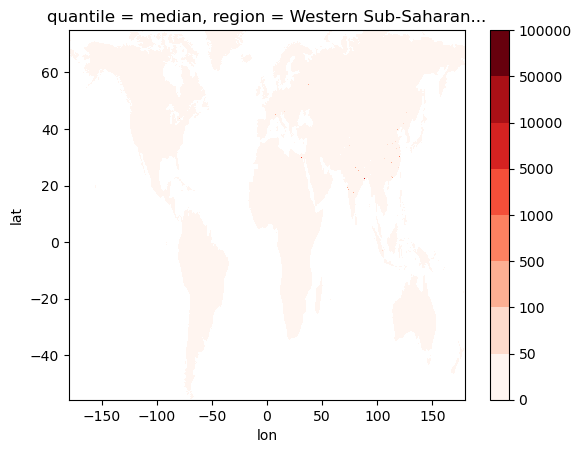

In [19]:
M.sel(quantile="median").plot(cmap="Reds", levels=levels)